<a href="https://colab.research.google.com/github/europecodingschool/ECS---VB---YZ---08.26/blob/main/VB_YZ_Ders_16_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
veri = pd.read_csv("/content/eticaret_iade.csv")

In [7]:
veri.head()

,kategori,urun_fiyati,indirim_orani,sepetteki_urun_sayisi,beden_tablosuna_bakti,onceki_siparis_sayisi,onceki_iade_orani,musteri_yasi,urun_puani,teslimat_suresi_gun,odeme_yontemi,kampanya_gunu,siparis_saati,iade_edildi
0,Ev,560.0,0.2,2,0,0,NaN,NaN,3.8,2,Kapida odeme,0,2,0
1,Ayakkabi,710.0,0.2,3,0,1,0.20,54.0,3.3,3,Kapida odeme,0,22,1
2,Ev,1650.0,0.2,1,0,9,0.09,24.0,NaN,2,Kapida odeme,0,13,1
3,Ev,2680.0,0.0,2,0,15,0.04,34.0,4.1,4,Kart,0,2,0
4,Giyim,520.0,0.0,2,1,1,0.12,30.0,4.2,5,Kart,0,9,0


In [9]:
veri.shape

(4000, 14)

In [11]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   kategori               4000 non-null   object 
 1   urun_fiyati            4000 non-null   float64
 2   indirim_orani          4000 non-null   float64
 3   sepetteki_urun_sayisi  4000 non-null   int64  
 4   beden_tablosuna_bakti  4000 non-null   int64  
 5   onceki_siparis_sayisi  4000 non-null   int64  
 6   onceki_iade_orani      3474 non-null   float64
 7   musteri_yasi           3513 non-null   float64
 8   urun_puani             3449 non-null   float64
 9   teslimat_suresi_gun    4000 non-null   int64  
 10  odeme_yontemi          4000 non-null   object 
 11  kampanya_gunu          4000 non-null   int64  
 12  siparis_saati          4000 non-null   int64  
 13  iade_edildi            4000 non-null   int64  
dtypes: float64(5), int64(7), object(2)
memory usage: 437.6+ 

In [15]:
veri.isnull().sum()


,0
kategori,0
urun_fiyati,0
indirim_orani,0
sepetteki_urun_sayisi,0
beden_tablosuna_bakti,0
onceki_siparis_sayisi,0
onceki_iade_orani,526
musteri_yasi,487
urun_puani,551
teslimat_suresi_gun,0


In [17]:
print("Eksik Oranları:")
print((veri.isnull().mean()*100))

Eksik Oranları:
kategori                  0.000
urun_fiyati               0.000
indirim_orani             0.000
sepetteki_urun_sayisi     0.000
beden_tablosuna_bakti     0.000
onceki_siparis_sayisi     0.000
onceki_iade_orani        13.150
musteri_yasi             12.175
urun_puani               13.775
teslimat_suresi_gun       0.000
odeme_yontemi             0.000
kampanya_gunu             0.000
siparis_saati             0.000
iade_edildi               0.000
dtype: float64


In [19]:
veri['iade_edildi'].value_counts()

,count
iade_edildi,
0,2834
1,1166


In [21]:
veri['iade_edildi'].value_counts(normalize=True) # siparişlerin %29,15 i iade edilmiş.

,proportion
iade_edildi,
0,0.7085
1,0.2915


In [24]:
# kategoriye göre iade oranı grafiği. kind bar veya barh
#iade grupby oluştur ortalamaları içeren.

kategori_iade = veri.groupby("kategori")["iade_edildi"].mean().sort_values()
kategori_iade


,iade_edildi
kategori,
Kozmetik,0.031185
Ev,0.082697
Elektronik,0.132879
Giyim,0.457722
Ayakkabi,0.493706


<function matplotlib.pyplot.show(close=None, block=None)>

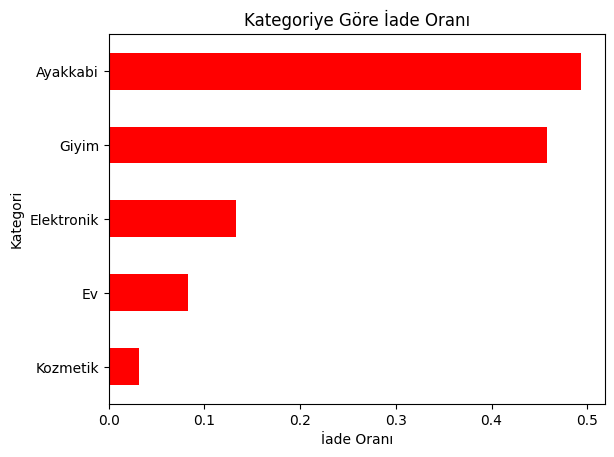

In [27]:
kategori_iade.plot(kind="barh", color="r")
plt.xlabel("İade Oranı")
plt.ylabel("Kategori")
plt.title("Kategoriye Göre İade Oranı")
plt.show

In [28]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   kategori               4000 non-null   object 
 1   urun_fiyati            4000 non-null   float64
 2   indirim_orani          4000 non-null   float64
 3   sepetteki_urun_sayisi  4000 non-null   int64  
 4   beden_tablosuna_bakti  4000 non-null   int64  
 5   onceki_siparis_sayisi  4000 non-null   int64  
 6   onceki_iade_orani      3474 non-null   float64
 7   musteri_yasi           3513 non-null   float64
 8   urun_puani             3449 non-null   float64
 9   teslimat_suresi_gun    4000 non-null   int64  
 10  odeme_yontemi          4000 non-null   object 
 11  kampanya_gunu          4000 non-null   int64  
 12  siparis_saati          4000 non-null   int64  
 13  iade_edildi            4000 non-null   int64  
dtypes: float64(5), int64(7), object(2)
memory usage: 437.6+ 

In [32]:
# Modele Hazırlık - XG BOOST algoritması eksik değerleri kendisi yönetebiliyor.

veri_model = pd.get_dummies(veri, columns=["kategori", "odeme_yontemi"], drop_first=True, dtype=int)
veri_model.head()

#

,urun_fiyati,indirim_orani,sepetteki_urun_sayisi,beden_tablosuna_bakti,onceki_siparis_sayisi,onceki_iade_orani,musteri_yasi,urun_puani,teslimat_suresi_gun,kampanya_gunu,siparis_saati,iade_edildi,kategori_Elektronik,kategori_Ev,kategori_Giyim,kategori_Kozmetik,odeme_yontemi_Kart
0,560.0,0.2,2,0,0,NaN,NaN,3.8,2,0,2,0,0,1,0,0,0
1,710.0,0.2,3,0,1,0.20,54.0,3.3,3,0,22,1,0,0,0,0,0
2,1650.0,0.2,1,0,9,0.09,24.0,NaN,2,0,13,1,0,1,0,0,0
3,2680.0,0.0,2,0,15,0.04,34.0,4.1,4,0,2,0,0,1,0,0,1
4,520.0,0.0,2,1,1,0.12,30.0,4.2,5,0,9,0,0,0,1,0,1


In [35]:
X= veri_model.drop("iade_edildi", axis=1)
y= veri_model["iade_edildi"]

print(X.shape)

(4000, 16)


In [37]:
# Train ve Test olarak ayırma

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(3200, 16) (3200,)
(800, 16) (800,)


In [40]:
#XGBOOST
#!pip install xgboost - farklı bir notbook kullansaydık önce kütüphaneyi kurmamız gerekirdi.

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, roc_auc_score

xgb_varsayilan = XGBClassifier(random_state=42)
xgb_varsayilan.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [44]:
print("Eğitim dogruluk:", xgb_varsayilan.score(X_train, y_train))
print("Test dogruluk:", xgb_varsayilan.score(X_test, y_test))
print( "AUC score:", roc_auc_score(y_test, xgb_varsayilan.predict(X_test)))

Eğitim dogruluk: 0.9971875
Test dogruluk: 0.795
AUC score: 0.7403471323356874


In [ ]:
# Önümüzdeki ders parametrelerle oynama ve eksik değerleri doldurup tekrar modele öğretme deneyi.